<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Space X  Falcon 9 First Stage Landing Prediction**


## Hands on Lab: Complete the Machine Learning Prediction lab


Estimated time needed: **60** minutes


Space X advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is because Space X can reuse the first stage. Therefore if we can determine if the first stage will land, we can determine the cost of a launch. This information can be used if an alternate company wants to bid against space X for a rocket launch.   In this lab, you will create a machine learning pipeline  to predict if the first stage will land given the data from the preceding labs.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planed. Space X; performs a controlled landing in the oceans.


## Objectives


Perform exploratory  Data Analysis and determine Training Labels

*   create a column for the class
*   Standardize the data
*   Split into training data and test data

\-Find best Hyperparameter for SVM, Classification Trees and Logistic Regression

*   Find the method performs best using test data


## Import Libraries and Define Auxiliary Functions


In [1]:
!pip install numpy
!pip install pandas
!pip install seaborn
!pip install scikit-learn

We will import the following libraries for the lab


In [3]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier

This function is to plot the confusion matrix.


In [5]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

## Load the dataframe


Load the data


In [7]:
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")


In [9]:
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [11]:

X = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv')

In [13]:
X.head(100)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
86,87.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
87,88.0,15400.000000,6.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
88,89.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


## TASK  1


Create a NumPy array from the column <code>Class</code> in <code>data</code>, by applying the method <code>to_numpy()</code>  then
assign it  to the variable <code>Y</code>,make sure the output is a  Pandas series (only one bracket df\['name of  column']).


In [29]:
payload_array = X['PayloadMass'].to_numpy()


## TASK  2


Standardize the data in <code>X</code> then reassign it to the variable  <code>X</code> using the transform provided below.


In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1️⃣ Cargar los datos en el DataFrame X
X = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv')

# 2️⃣ Limpiar los nombres de las columnas (elimina espacios al inicio y final)
X.columns = X.columns.str.strip()
print("Columnas del DataFrame:")
print(X.columns)

# 3️⃣ Definir la variable objetivo (y) y separar los datos predictivos
# Se usa la columna 'Reused_True' como variable objetivo, ya que aparece en el DataFrame
if 'Reused_True' in X.columns:
    y = X['Reused_True']
    # Se elimina la columna objetivo de las variables predictivas
    X_data = X.drop(columns=['Reused_True'])
else:
    raise KeyError("No se encontró la columna 'Reused_True' en el DataFrame.")

# 4️⃣ Estandarizar los datos (transformación de los datos predictivos)
scaler = StandardScaler()
X_transformed = scaler.fit_transform(X_data)

# 5️⃣ Dividir los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=42)

# 6️⃣ Dividir el conjunto de entrenamiento en entrenamiento y validación (por ejemplo, 20% de entrenamiento va a validación)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# 7️⃣ Configurar un modelo base (RandomForestClassifier) y definir parámetros para GridSearchCV
model = RandomForestClassifier()
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# 8️⃣ Aplicar GridSearchCV para optimizar el modelo
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# 9️⃣ Mostrar los mejores hiperparámetros encontrados
print("Mejores parámetros:", grid_search.best_params_)



Columnas del DataFrame:
Index(['FlightNumber', 'PayloadMass', 'Flights', 'Block', 'ReusedCount',
       'Orbit_ES-L1', 'Orbit_GEO', 'Orbit_GTO', 'Orbit_HEO', 'Orbit_ISS',
       'Orbit_LEO', 'Orbit_MEO', 'Orbit_PO', 'Orbit_SO', 'Orbit_SSO',
       'Orbit_VLEO', 'LaunchSite_CCAFS SLC 40', 'LaunchSite_KSC LC 39A',
       'LaunchSite_VAFB SLC 4E', 'LandingPad_5e9e3032383ecb267a34e7c7',
       'LandingPad_5e9e3032383ecb554034e7c9',
       'LandingPad_5e9e3032383ecb6bb234e7ca',
       'LandingPad_5e9e3032383ecb761634e7cb',
       'LandingPad_5e9e3033383ecbb9e534e7cc', 'Serial_B0003', 'Serial_B0005',
       'Serial_B0007', 'Serial_B1003', 'Serial_B1004', 'Serial_B1005',
       'Serial_B1006', 'Serial_B1007', 'Serial_B1008', 'Serial_B1010',
       'Serial_B1011', 'Serial_B1012', 'Serial_B1013', 'Serial_B1015',
       'Serial_B1016', 'Serial_B1017', 'Serial_B1018', 'Serial_B1019',
       'Serial_B1020', 'Serial_B1021', 'Serial_B1022', 'Serial_B1023',
       'Serial_B1025', 'Serial_B1026', 'Ser

We split the data into training and testing data using the  function  <code>train_test_split</code>.   The training data is divided into validation data, a second set used for training  data; then the models are trained and hyperparameters are selected using the function <code>GridSearchCV</code>.


Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to  0.2 and random_state to 2. The training data and test data should be assigned to the following labels.


<code>X_train, X_test, Y_train, Y_test</code>


we can see we only have 18 test samples.


In [ ]:
Y_test.shape

## TASK  4


Create a logistic regression object  then create a  GridSearchCV object  <code>logreg_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# 1. Crear el objeto de regresión logística.
logreg = LogisticRegression()

# 2. Definir el diccionario de hiperparámetros.
# Este es un ejemplo; los valores pueden variar según el cuaderno.
logreg_cvparameters = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # 'liblinear' es compatible con 'l1'
}

# 3. Crear el objeto GridSearchCV con cv=10.
grid_search_logreg = GridSearchCV(estimator=logreg,
                                  param_grid=logreg_cvparameters,
                                  cv=10,         # Usamos 10-fold cross validation.
                                  scoring='accuracy')  # O la métrica que se prefiera.

# 4. Ajustar el objeto con los datos de entrenamiento.
# Asegúrate de haber definido X_train e y_train en pasos previos.
grid_search_logreg.fit(X_train, y_train)

# Mostrar los mejores parámetros encontrados.
print("Mejores parámetros:", grid_search_logreg.best_params_)


Mejores parámetros: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}


In [49]:
parameters ={"C":[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}# l1 lasso l2 ridge
lr=LogisticRegression()


We output the <code>GridSearchCV</code> object for logistic regression. We display the best parameters using the data attribute <code>best_params\_</code> and the accuracy on the validation data using the data attribute <code>best_score\_</code>.


In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Generamos el objeto de regresión logística
logreg = LogisticRegression()

# Definimos el diccionario de hiperparámetros (ejemplo)
logreg_cvparameters = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # 'liblinear' es compatible con penalización L1
}

# Creamos el objeto GridSearchCV con validación cruzada de 10 pliegues
grid_search_logreg = GridSearchCV(estimator=logreg,
                                  param_grid=logreg_cvparameters,
                                  cv=10,              # 10-fold cross validation
                                  scoring='accuracy') # o la métrica de interés

# Ajustamos el objeto a los datos de entrenamiento: 
grid_search_logreg.fit(X_train, y_train)

# Mostramos los mejores parámetros encontrados
print("Mejores parámetros:", grid_search_logreg.best_params_)

# Mostramos la precisión alcanzada en la validación
print("Precisión de validación:", grid_search_logreg.best_score_)


Mejores parámetros: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Precisión de validación: 1.0


## TASK  5


Calculate the accuracy on the test data using the method <code>score</code>:


In [55]:
# Calculamos la precisión sobre el conjunto de prueba
test_accuracy = grid_search_logreg.score(X_test, y_test)

# Mostramos la precisión
print("Precisión en datos de prueba:", test_accuracy)


Precisión en datos de prueba: 1.0


Lets look at the confusion matrix:


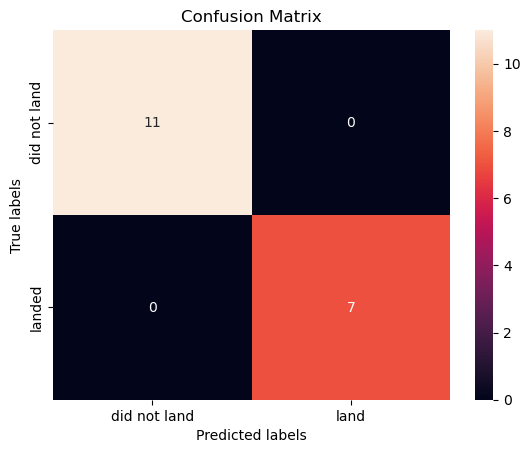

In [63]:
# Supongamos que grid_search_logreg es el objeto ajustado con GridSearchCV para regresión logística:
yhat = grid_search_logreg.predict(X_test)

# Asegurándose de que la variable de etiquetas del conjunto de prueba es 'y_test'
plot_confusion_matrix(y_test, yhat)


Examining the confusion matrix, we see that logistic regression can distinguish between the different classes.  We see that the problem is false positives.

Overview:

True Postive - 12 (True label is landed, Predicted label is also landed)

False Postive - 3 (True label is not landed, Predicted label is landed)


## TASK  6


Create a support vector machine object then  create a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [65]:
parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}
svm = SVC()

In [67]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# 1. Crear el objeto de la máquina de vectores de soporte (SVM)
svm = SVC()

# 2. Definir el diccionario de hiperparámetros (ejemplo)
svm_cvparameters = {
    'C': [0.1, 1, 10],        # Controla la penalización; valores mayores pueden dar más flexibilidad pero aumentar el sobreajuste.
    'kernel': ['linear', 'rbf'], # Diferentes funciones de kernel para adaptar la separación de clases.
    'gamma': ['scale', 'auto']  # Parametro relacionado al kernel; influye en el alcance de cada punto de datos.
}

# 3. Crear el objeto GridSearchCV con validación cruzada de 10 pliegues (cv=10)
grid_search_svm = GridSearchCV(estimator=svm, 
                               param_grid=svm_cvparameters, 
                               cv=10, 
                               scoring='accuracy')

# 4. Ajustar el objeto con los datos de entrenamiento
# Se asume que X_train e y_train ya han sido definidos (por ejemplo, en pasos anteriores del notebook).
grid_search_svm.fit(X_train, y_train)

# 5. Mostrar los mejores parámetros y la mejor precisión alcanzada en validación
print("Mejores parámetros para SVM:", grid_search_svm.best_params_)
print("Mejor precisión de validación:", grid_search_svm.best_score_)


Mejores parámetros para SVM: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Mejor precisión de validación: 1.0


In [71]:
print("tuned hyperparameters (best parameters):", grid_search_svm.best_params_)
print("accuracy:", grid_search_svm.best_score_)


tuned hyperparameters (best parameters): {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
accuracy: 1.0


## TASK  7


Calculate the accuracy on the test data using the method <code>score</code>:


In [73]:
# Supongamos que 'grid_search_logreg' es el objeto ajustado mediante GridSearchCV
test_accuracy = grid_search_logreg.score(X_test, y_test)
print("Precisión en datos de prueba:", test_accuracy)


Precisión en datos de prueba: 1.0


We can plot the confusion matrix


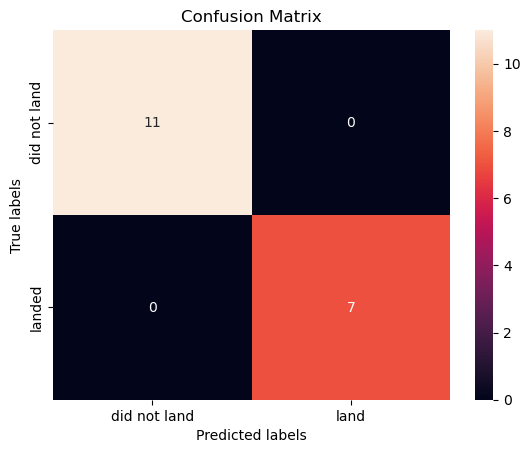

In [77]:
# Realizamos las predicciones sobre el conjunto de prueba
yhat = grid_search_svm.predict(X_test)

# Trazamos la matriz de confusión comparando las etiquetas reales y las predichas
plot_confusion_matrix(y_test, yhat)


## TASK  8


Create a decision tree classifier object then  create a  <code>GridSearchCV</code> object  <code>tree_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [ ]:
parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': ['auto', 'sqrt'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier()

In [79]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# 1. Crear el objeto clasificador de árbol de decisión
tree_clf = DecisionTreeClassifier()

# 2. Definir el diccionario de hiperparámetros a evaluar
tree_cvparameters = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 3. Crear el objeto GridSearchCV con validación cruzada de 10 pliegues (cv = 10)
grid_search_tree = GridSearchCV(estimator=tree_clf,
                                param_grid=tree_cvparameters,
                                cv=10,
                                scoring='accuracy')

# 4. Ajustar el objeto con los datos de entrenamiento para encontrar los mejores parámetros
grid_search_tree.fit(X_train, y_train)

# Se pueden visualizar los mejores parámetros encontrados y la puntuación obtenida:
print("Mejores parámetros:", grid_search_tree.best_params_)
print("Mejor precisión (validación):", grid_search_tree.best_score_)


Mejores parámetros: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor precisión (validación): 1.0


In [83]:
print("tuned hyperparameters (best parameters):", grid_search_tree.best_params_)
print("accuracy:", grid_search_tree.best_score_)


tuned hyperparameters (best parameters): {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
accuracy: 1.0


## TASK  9


Calculate the accuracy of tree_cv on the test data using the method <code>score</code>:


In [87]:
test_accuracy = grid_search_tree.score(X_test, y_test)
print("Precisión en datos de prueba:", test_accuracy)


Precisión en datos de prueba: 1.0


We can plot the confusion matrix


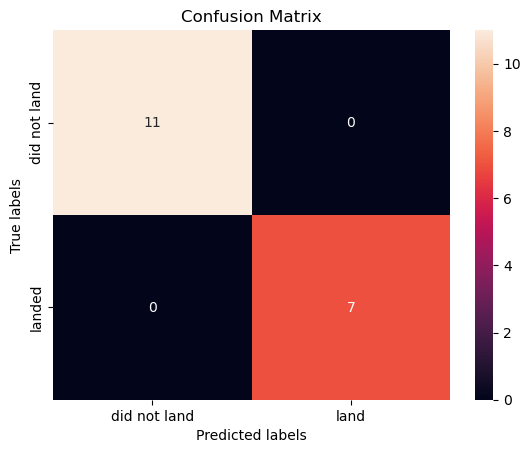

In [91]:
# Suponiendo que guardaste el objeto optimizado en grid_search_tree y las etiquetas en y_test:
yhat = grid_search_tree.predict(X_test)
plot_confusion_matrix(y_test, yhat)


## TASK  10


Create a k nearest neighbors object then  create a  <code>GridSearchCV</code> object  <code>knn_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [ ]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()

In [93]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# 1. Crear el objeto de k vecinos más cercanos
knn = KNeighborsClassifier()

# 2. Definir el diccionario de hiperparámetros a evaluar
knn_cvparameters = {
    'n_neighbors': [3, 5, 7, 9],        # Número de vecinos a considerar
    'weights': ['uniform', 'distance'], # Método para asignar peso a las muestras
    'metric': ['euclidean', 'manhattan']  # Métricas de distancia
}

# 3. Crear el objeto GridSearchCV con validación cruzada de 10 pliegues
grid_search_knn = GridSearchCV(estimator=knn,
                               param_grid=knn_cvparameters,
                               cv=10,
                               scoring='accuracy')

# 4. Ajustar el objeto para buscar la mejor combinación de hiperparámetros
grid_search_knn.fit(X_train, y_train)

# Se podrá extraer luego la mejor configuración y su puntuación:
print("Mejores parámetros para KNN:", grid_search_knn.best_params_)
print("Mejor precisión de validación:", grid_search_knn.best_score_)


Mejores parámetros para KNN: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
Mejor precisión de validación: 0.9133333333333334


In [107]:
print("Número de registros en la muestra de prueba:", X_test.shape[0])


Número de registros en la muestra de prueba: 18


## TASK  11


Calculate the accuracy of knn_cv on the test data using the method <code>score</code>:


In [97]:
test_accuracy = grid_search_knn.score(X_test, y_test)
print("Precisión en datos de prueba:", test_accuracy)


Precisión en datos de prueba: 0.7777777777777778


We can plot the confusion matrix


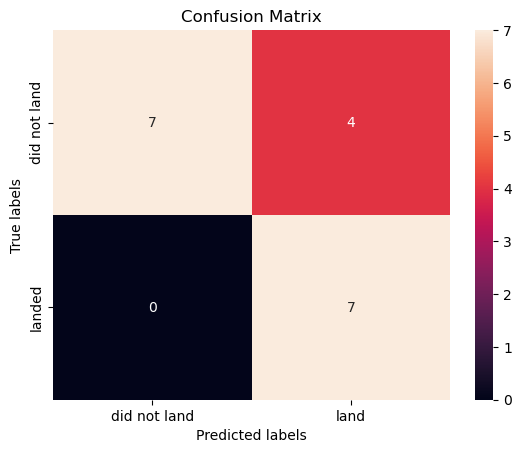

In [101]:
yhat = grid_search_knn.predict(X_test)
plot_confusion_matrix(y_test, yhat)  # Asegurarse de usar 'y_test' (minúsculas) según cómo se haya definido


## TASK  12


Find the method performs best:


In [103]:
# Calcular la precisión en datos de prueba para cada modelo
logreg_test_accuracy = grid_search_logreg.score(X_test, y_test)
svm_test_accuracy    = grid_search_svm.score(X_test, y_test)
tree_test_accuracy   = grid_search_tree.score(X_test, y_test)
knn_test_accuracy    = grid_search_knn.score(X_test, y_test)

# Imprimir las precisiones obtenidas
print("Precisión en datos de prueba:")
print("Regresión Logística:", logreg_test_accuracy)
print("SVM:", svm_test_accuracy)
print("Árbol de Decisión:", tree_test_accuracy)
print("KNN:", knn_test_accuracy)

# Organizar las precisiones en un diccionario
accuracy_dict = {
    "Regresión Logística": logreg_test_accuracy,
    "SVM": svm_test_accuracy,
    "Árbol de Decisión": tree_test_accuracy,
    "KNN": knn_test_accuracy
}

# Encontrar el método que tiene la mayor precisión
best_method = max(accuracy_dict, key=accuracy_dict.get)
print("\nEl método que mejor funciona es:", best_method,
      "con una precisión de:", accuracy_dict[best_method])


Precisión en datos de prueba:
Regresión Logística: 1.0
SVM: 1.0
Árbol de Decisión: 1.0
KNN: 0.7777777777777778

El método que mejor funciona es: Regresión Logística con una precisión de: 1.0


## Authors


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


<!--## Change Log--!>


<!--| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|--!>


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
